# 기본 셋팅

In [17]:
# ==========================================================
# 1. Import Library
# ==========================================================
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Data Split & Hyperparameter Tuning
from sklearn.model_selection import (
    train_test_split,
    RandomizedSearchCV
)

# Scaling
from sklearn.preprocessing import MinMaxScaler

# Evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    ConfusionMatrixDisplay
)

# Imbalanced Data
from imblearn.over_sampling import SMOTE

# Random Forest
from sklearn.ensemble import RandomForestClassifier

# ==========================================================
# 2. Load Dataset
# ==========================================================

df = pd.read_csv("ai4i2020.csv")

# 컬럼명 공백 제거
df.columns = df.columns.str.strip()

print("=" * 60)
print("Dataset Shape")
print("=" * 60)
print(df.shape)

print()

print("=" * 60)
print("Dataset Information")
print("=" * 60)
print(df.info())

print()

print("=" * 60)
print("Machine Failure Distribution")
print("=" * 60)
print(df["Machine failure"].value_counts())

display(df.head())

Dataset Shape
(10000, 14)

Dataset Information
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  str    
 2   Type                     10000 non-null  str    
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [18]:
# ==========================================================
# 3. Preprocessing
# ==========================================================

# Product ID 제거
df = df.drop(columns=["Product ID"])

# Type One-Hot Encoding
df = pd.get_dummies(
    df,
    columns=["Type"],
    drop_first=True
)

# Feature / Target
X = df.drop(columns=[
    "Machine failure",
    "TWF",
    "HDF",
    "PWF",
    "OSF",
    "RNF"
])

y = df["Machine failure"]

# Train / Test Split
X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.2,

    random_state=49,

    stratify=y

)

# Scaling
scaler = MinMaxScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# SMOTE
sm = SMOTE(random_state=42)

X_train_sm, y_train_sm = sm.fit_resample(
    X_train,
    y_train
)

print("=" * 60)
print("Train Shape")
print("=" * 60)
print(X_train.shape)

print()

print("=" * 60)
print("After SMOTE")
print("=" * 60)
print(pd.Series(y_train_sm).value_counts())

Train Shape
(8000, 8)

After SMOTE
Machine failure
0    7729
1    7729
Name: count, dtype: int64


In [19]:
# ==========================================================
# 4. Result Function
# ==========================================================

results = []

def evaluate_model(model_name, model, X_test, y_test, threshold=0.3):

    proba = model.predict_proba(X_test)

    pred = (proba[:,1] > threshold).astype(int)

    acc = accuracy_score(y_test, pred)
    pre = precision_score(y_test, pred)
    rec = recall_score(y_test, pred)
    f1 = f1_score(y_test, pred)

    print("=" * 60)
    print(model_name)
    print("=" * 60)

    print(classification_report(y_test, pred))

    ConfusionMatrixDisplay.from_predictions(
        y_test,
        pred
    )

    plt.title(model_name)
    plt.show()

    results.append({
        "Model": model_name,
        "Accuracy": acc,
        "Precision": pre,
        "Recall": rec,
        "F1-score": f1
    })

# Hyperparameter

Random Forest - Base
              precision    recall  f1-score   support

           0       0.99      0.95      0.97      1932
           1       0.35      0.85      0.50        68

    accuracy                           0.94      2000
   macro avg       0.67      0.90      0.73      2000
weighted avg       0.97      0.94      0.95      2000



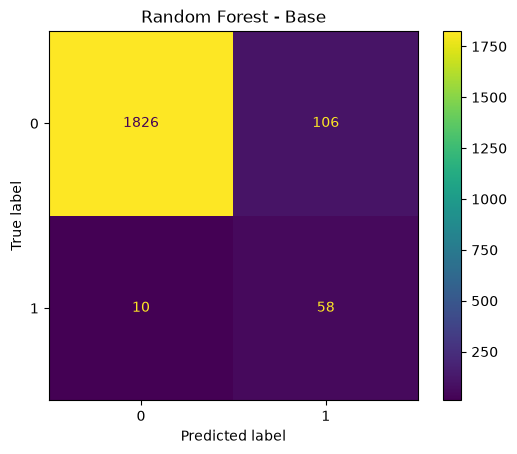

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best Parameter
{'n_estimators': 300, 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': None, 'class_weight': {0: 1, 1: 8}}

Best Recall : 0.9958596147485734
Random Forest - Hyperparameter
              precision    recall  f1-score   support

           0       1.00      0.85      0.92      1932
           1       0.18      0.96      0.31        68

    accuracy                           0.85      2000
   macro avg       0.59      0.90      0.61      2000
weighted avg       0.97      0.85      0.90      2000



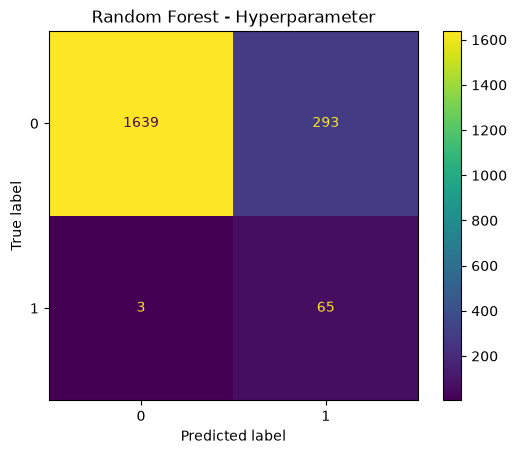

In [20]:
# ==========================================================
# 5. Random Forest - Base Model
# ==========================================================

rf_base = RandomForestClassifier(

    n_estimators=500,

    max_depth=15,

    min_samples_leaf=2,

    class_weight="balanced",

    random_state=42

)

rf_base.fit(

    X_train_sm,

    y_train_sm

)

evaluate_model(

    "Random Forest - Base",

    rf_base,

    X_test,

    y_test

)

# ==========================================================
# 6. Random Forest - Hyperparameter Tuning
# ==========================================================

param_dist = {

    "n_estimators":[100,200,300,500],

    "max_depth":[5,10,15,20,None],

    "min_samples_split":[2,5,10],

    "min_samples_leaf":[1,2,4],

    "max_features":[
        "sqrt",
        "log2"
    ],

    "class_weight":[
        "balanced",
        {0:1,1:3},
        {0:1,1:5},
        {0:1,1:8}
    ]

}

rf_random = RandomizedSearchCV(

    estimator=RandomForestClassifier(

        random_state=42

    ),

    param_distributions=param_dist,

    n_iter=20,

    scoring="recall",

    cv=5,

    random_state=42,

    verbose=1,

    n_jobs=1      # VSCode 추천

)

rf_random.fit(

    X_train_sm,

    y_train_sm

)

print("="*60)
print("Best Parameter")
print("="*60)

print(rf_random.best_params_)

print()

print("Best Recall :", rf_random.best_score_)

rf_best = rf_random.best_estimator_

evaluate_model(

    "Random Forest - Hyperparameter",

    rf_best,

    X_test,

    y_test

)

# Feature Engineering

Random Forest - Feature
              precision    recall  f1-score   support

           0       1.00      0.95      0.97      1932
           1       0.39      0.90      0.54        68

    accuracy                           0.95      2000
   macro avg       0.69      0.92      0.76      2000
weighted avg       0.98      0.95      0.96      2000



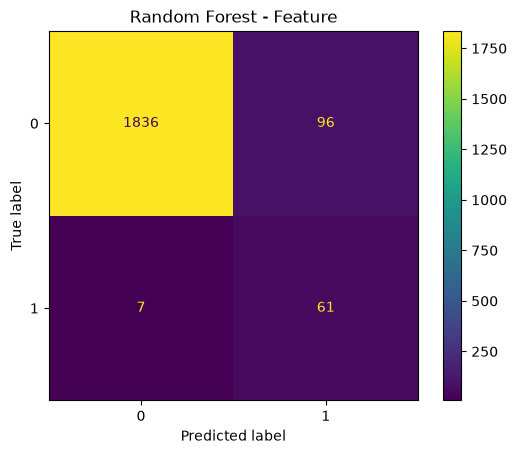

In [21]:
# ==========================================================
# 7. Feature Engineering
# ==========================================================

df_feature = df.copy()

# 출력(Power)
df_feature["Power"] = (
    df_feature["Rotational speed [rpm]"]
    * df_feature["Torque [Nm]"]
)

# 온도차
df_feature["Temp_diff"] = (
    df_feature["Process temperature [K]"]
    - df_feature["Air temperature [K]"]
)

# 출력 × 공구마모
df_feature["Power_wear"] = (
    df_feature["Power"]
    * df_feature["Tool wear [min]"]
)

# 토크 / 회전속도
df_feature["Torque_per_RPM"] = (
    df_feature["Torque [Nm]"]
    / (df_feature["Rotational speed [rpm]"] + 1)
)

# 공구마모 × 토크
df_feature["Torque_wear"] = (
    df_feature["Torque [Nm]"]
    * df_feature["Tool wear [min]"]
)

# 온도차 × 토크
df_feature["Temp_Torque"] = (
    df_feature["Temp_diff"]
    * df_feature["Torque [Nm]"]
)

# 공정온도 / 외기온도
df_feature["Temp_ratio"] = (
    df_feature["Process temperature [K]"]
    / df_feature["Air temperature [K]"]
)

# -----------------------------
# X, y 생성
# -----------------------------

X = df_feature.drop(columns=[
    "Machine failure",
    "TWF",
    "HDF",
    "PWF",
    "OSF",
    "RNF"
])

y = df_feature["Machine failure"]

# Train / Test
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=49,
    stratify=y
)

# Scaling
scaler = MinMaxScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# SMOTE
sm = SMOTE(random_state=42)

X_train_sm, y_train_sm = sm.fit_resample(
    X_train,
    y_train
)

# -----------------------------
# RandomForest
# -----------------------------

rf_feature = RandomForestClassifier(

    n_estimators=500,

    max_depth=15,

    min_samples_leaf=2,

    class_weight="balanced",

    random_state=42

)

rf_feature.fit(
    X_train_sm,
    y_train_sm
)

evaluate_model(
    "Random Forest - Feature",
    rf_feature,
    X_test,
    y_test
)

# Feature + Hyperparameter

In [ ]:
# ==========================================================
# 8. Feature + Hyperparameter Tuning
# ==========================================================

param_dist = {

    "n_estimators": [100, 200, 300, 500],

    "max_depth": [5, 10, 15, 20, None],

    "min_samples_split": [2, 5, 10],

    "min_samples_leaf": [1, 2, 4],

    "max_features": ["sqrt", "log2"],

    "class_weight": [
        "balanced",
        {0:1, 1:3},
        {0:1, 1:5},
        {0:1, 1:8}
    ]
}

rf_random = RandomizedSearchCV(

    estimator=RandomForestClassifier(
        random_state=42
    ),

    param_distributions=param_dist,

    n_iter=20,

    scoring="recall",

    cv=5,

    random_state=42,

    verbose=1,

    n_jobs=1

)

rf_random.fit(
    X_train_sm,
    y_train_sm
)

print("="*60)
print("Best Parameter")
print("="*60)

print(rf_random.best_params_)

rf_feature_tune = rf_random.best_estimator_

evaluate_model(
    "Random Forest - Feature + Hyperparameter",
    rf_feature_tune,
    X_test,
    y_test
)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


# Feature Importance + Result

In [ ]:
# ==========================================================
# 9. Result Comparison
# ==========================================================

result_df = pd.DataFrame(results)

display(result_df)

print("="*60)
print("Best Model")
print("="*60)

display(
    result_df.sort_values(
        by="F1-score",
        ascending=False
    )
)

,Model,Accuracy,Precision,Recall,F1-score
0,Random Forest - Base,0.9420,0.353659,0.852941,0.500000
1,Random Forest - Hyperparameter,0.8520,0.181564,0.955882,0.305164
2,Random Forest - Feature,0.9485,0.388535,0.897059,0.542222
3,Random Forest - Feature + Hyperparameter,0.8835,0.220339,0.955882,0.358127


Best Model


,Model,Accuracy,Precision,Recall,F1-score
2,Random Forest - Feature,0.9485,0.388535,0.897059,0.542222
0,Random Forest - Base,0.9420,0.353659,0.852941,0.500000
3,Random Forest - Feature + Hyperparameter,0.8835,0.220339,0.955882,0.358127
1,Random Forest - Hyperparameter,0.8520,0.181564,0.955882,0.305164
